In [1]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.graph_objects as go
import plotly.express as px

import time
from datetime import date

# for graphs
import matplotlib.pyplot as plt

# For Decision Trees
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score


In [2]:
pd.set_option('display.max_rows', None)

In [3]:
# full dataset for 33 stocks
df_full = pd.read_parquet("stocks_df_combined_2026_09_18.parquet.brotli")

In [4]:
df_full.info()

<class 'pandas.DataFrame'>
Index: 240759 entries, 0 to 6018
Columns: 203 entries, Open to growth_btc_usd_365d
dtypes: datetime64[ns](3), float64(129), int32(64), int64(5), str(2)
memory usage: 317.7 MB


In [5]:
df_full.keys()

Index(['Open', 'High', 'Low', 'Close_x', 'Volume', 'Dividends', 'Stock Splits',
       'Ticker', 'Year', 'Month',
       ...
       'growth_brent_oil_7d', 'growth_brent_oil_30d', 'growth_brent_oil_90d',
       'growth_brent_oil_365d', 'growth_btc_usd_1d', 'growth_btc_usd_3d',
       'growth_btc_usd_7d', 'growth_btc_usd_30d', 'growth_btc_usd_90d',
       'growth_btc_usd_365d'],
      dtype='str', length=203)

In [6]:
# growth indicators (but not future growth)
GROWTH = [g for g in df_full.keys() if (g.find('growth_')==0)&(g.find('future')<0)]

In [7]:
OHLCV = ['Open','High','Low','Close','Adj Close_x','Volume']

In [8]:
CATEGORICAL = ['Month', 'Weekday', 'Ticker', 'ticker_type']

In [9]:
TO_PREDICT = [g for g in df_full.keys() if (g.find('future')>=0)]
TO_PREDICT

['growth_future_30d', 'is_positive_growth_30d_future']

In [10]:
TO_DROP = ['Year','Date','index_x', 'index_y', 'index', 'Quarter','Adj Close_y'] + CATEGORICAL + OHLCV
TO_DROP

['Year',
 'Date',
 'index_x',
 'index_y',
 'index',
 'Quarter',
 'Adj Close_y',
 'Month',
 'Weekday',
 'Ticker',
 'ticker_type',
 'Open',
 'High',
 'Low',
 'Close',
 'Adj Close_x',
 'Volume']

In [11]:
df_full['ln_volume'] = df_full.Volume.replace(0, np.nan).apply(np.log)

In [12]:
# manually defined features
CUSTOM_NUMERICAL = ['SMA10', 'SMA20', 'growing_moving_average', 'high_minus_low_relative','volatility', 'ln_volume']

In [13]:
# All Supported Ta-lib indicators: https://github.com/TA-Lib/ta-lib-python/blob/master/docs/funcs.md

TECHNICAL_INDICATORS = ['adx', 'adxr', 'apo', 'aroon_1','aroon_2', 'aroonosc',
 'bop', 'cci', 'cmo','dx', 'macd', 'macdsignal', 'macdhist', 'macd_ext',
 'macdsignal_ext', 'macdhist_ext', 'macd_fix', 'macdsignal_fix',
 'macdhist_fix', 'mfi', 'minus_di', 'mom', 'plus_di', 'dm', 'ppo',
 'roc', 'rocp', 'rocr', 'rocr100', 'rsi', 'slowk', 'slowd', 'fastk',
 'fastd', 'fastk_rsi', 'fastd_rsi', 'trix', 'ultosc', 'willr',
 'ad', 'adosc', 'obv', 'atr', 'natr', 'ht_dcperiod', 'ht_dcphase',
 'ht_phasor_inphase', 'ht_phasor_quadrature', 'ht_sine_sine', 'ht_sine_leadsine',
 'ht_trendmod', 'avgprice', 'medprice', 'typprice', 'wclprice']

In [14]:
TECHNICAL_PATTERNS = [g for g in df_full.keys() if g.find('cdl')>=0]
print(f'Technical patterns count = {len(TECHNICAL_PATTERNS)}, examples = {TECHNICAL_PATTERNS[0:5]}')

Technical patterns count = 61, examples = ['cdl2crows', 'cdl3blackrows', 'cdl3inside', 'cdl3linestrike', 'cdl3outside']


In [15]:
MACRO = ['gdppot_us_yoy', 'gdppot_us_qoq', 'cpi_core_yoy', 'cpi_core_mom', 'FEDFUNDS',
 'DGS1', 'DGS5', 'DGS10']

In [16]:
NUMERICAL = GROWTH + TECHNICAL_INDICATORS + TECHNICAL_PATTERNS + CUSTOM_NUMERICAL + MACRO

In [17]:
# CHECK: NO OTHER INDICATORS LEFT
OTHER = [k for k in df_full.keys() if k not in OHLCV + CATEGORICAL + NUMERICAL + TO_DROP]
OTHER

['Close_x',
 'Dividends',
 'Stock Splits',
 'growth_future_30d',
 'is_positive_growth_30d_future',
 'Close_y']

In [18]:
df = df_full[df_full.Date>='2000-01-01']
df.info()

<class 'pandas.DataFrame'>
Index: 202292 entries, 3490 to 6018
Columns: 204 entries, Open to ln_volume
dtypes: datetime64[ns](3), float64(130), int32(64), int64(5), str(2)
memory usage: 268.6 MB


In [19]:
df[NUMERICAL].info()

<class 'pandas.DataFrame'>
Index: 202292 entries, 3490 to 6018
Columns: 184 entries, growth_1d to DGS10
dtypes: float64(121), int32(62), int64(1)
memory usage: 237.7 MB


#### Generating Dummies

In [20]:
CATEGORICAL

['Month', 'Weekday', 'Ticker', 'ticker_type']

In [21]:
df['Month'] = df['Month'].dt.strftime('%B')
df['Weekday'] = df['Weekday'].astype(str)

In [22]:
### Question 1: Dummies for Month and Week-of-Month
##Week of Month
df['week_of_month'] = df['Date'].dt.day.apply(lambda d: (d - 1) // 7 + 1)

In [23]:
# Creating the new category month_wom
df['month_wom'] = df['Month'] + '_w' + df['week_of_month'].astype(str)

In [24]:
# Updating categorical
CATEGORICAL = ['Month', 'Weekday', 'Ticker', 'ticker_type', 'month_wom']

In [25]:
# Creating the dummy variables
dummy_variables = pd.get_dummies(df[CATEGORICAL], dtype='int32')

In [26]:
DUMMIES = dummy_variables.columns.to_list()

In [27]:
# Merge into original df
df_with_dummies = pd.concat([df, dummy_variables], axis=1)

In [28]:
corr = df_with_dummies[NUMERICAL + DUMMIES + TO_PREDICT].corr()
corr_target = corr['is_positive_growth_30d_future'].drop('is_positive_growth_30d_future')

In [29]:
# Just seperating the Month of Week dummies
month_wom_dummies = [col for col in DUMMIES if col.startswith('month_wom')]
month_wom_corr = corr_target[month_wom_dummies].copy()

In [30]:
# Create DataFrame with absolute correlations
month_wom_corr_df = pd.DataFrame({
    'feature': month_wom_corr.index,
    'correlation': month_wom_corr.values,
})
month_wom_corr_df['abs_corr'] = month_wom_corr_df['correlation'].abs()

In [31]:
# Sort by absolute correlation
month_wom_corr_df_sorted = month_wom_corr_df.sort_values(by='abs_corr', ascending=False)

In [32]:
month_wom_corr_df_sorted.head(5)

,feature,correlation,abs_corr
53,month_wom_October_w4,0.024584,0.024584
47,month_wom_November_w3,0.023251,0.023251
15,month_wom_February_w1,-0.020861,0.020861
21,month_wom_January_w2,-0.019846,0.019846
24,month_wom_January_w5,-0.019792,0.019792


In [33]:
print(f"Most correlated dummy: {month_wom_corr_df_sorted.iloc[0]}")
print(f"Absolute correlation: {round(month_wom_corr_df_sorted.iloc[0]['abs_corr'], 3)}")

Most correlated dummy: feature        month_wom_October_w4
correlation                0.024584
abs_corr                   0.024584
Name: 53, dtype: object
Absolute correlation: 0.025


### Temporal split of ~25 years of data (by date)

In [34]:
def temporal_split(df, min_date, max_date, train_prop=0.7, val_prop=0.15, test_prop=0.15):
    """
    Splits a DataFrame into three buckets based on the temporal order of the 'Date' column.

    Args:
        df (DataFrame): The DataFrame to split.
        min_date (str or Timestamp): Minimum date in the DataFrame.
        max_date (str or Timestamp): Maximum date in the DataFrame.
        train_prop (float): Proportion of data for training set (default: 0.6).
        val_prop (float): Proportion of data for validation set (default: 0.2).
        test_prop (float): Proportion of data for test set (default: 0.2).

    Returns:
        DataFrame: The input DataFrame with a new column 'split' indicating the split for each row.
    """
    # Define the date intervals
    train_end = min_date + pd.Timedelta(days=(max_date - min_date).days * train_prop)
    val_end = train_end + pd.Timedelta(days=(max_date - min_date).days * val_prop)

    # Assign split labels based on date ranges
    split_labels = []
    for date in df['Date']:
        if date <= train_end:
            split_labels.append('train')
        elif date <= val_end:
            split_labels.append('validation')
        else:
            split_labels.append('test')

    # Add 'split' column to the DataFrame
    df['split'] = split_labels

    return df


In [35]:
min_date_df = df_with_dummies.Date.min()
max_date_df = df_with_dummies.Date.max()

df_with_dummies = temporal_split(df_with_dummies,
                                 min_date = min_date_df,
                                 max_date = max_date_df)

In [36]:
df_with_dummies['split'].value_counts()/len(df_with_dummies)

split
train         0.676458
test          0.163936
validation    0.159606
Name: count, dtype: float64

In [37]:
new_df = df_with_dummies.copy()

In [38]:
new_df.groupby(by='split')['growth_future_30d'].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,32173.0,1.024840,0.099602,0.588160,0.963423,1.018612,1.078930,1.648934
train,136842.0,1.023525,0.121019,0.246131,0.960703,1.020272,1.082224,5.179688
validation,32287.0,1.021737,0.106653,0.461847,0.960477,1.024186,1.084679,1.783609


In [39]:
new_df.groupby(['split'])['Date'].agg({'min','max','count'})

,min,max,count
split,,,
test,2022-09-16,2026-09-18,33163
train,2000-01-03,2018-09-13,136842
validation,2018-09-14,2022-09-15,32287


In [40]:
# generate manual predictions
# Let's label all prediction features with prefix "pred"
new_df['pred0_manual_cci'] = (new_df.cci>200).astype(int)
new_df['pred1_manual_prev_g1'] = (new_df.growth_30d>1).astype(int)
new_df['pred2_manual_prev_g1_and_snp'] = ((new_df['growth_30d'] > 1) & (new_df['growth_snp500_30d'] > 1)).astype(int)

In [41]:
PREDICTIONS = [k for k in new_df.keys() if k.startswith('pred')]

In [42]:
# generate columns is_correct_
for pred in PREDICTIONS:
  part1 = pred.split('_')[0] # first prefix before '_'
  new_df[f'is_correct_{part1}'] =  (new_df[pred] == new_df.is_positive_growth_30d_future).astype(int)


In [43]:
IS_CORRECT =  [k for k in new_df.keys() if k.startswith('is_correct_')]
IS_CORRECT

['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2']

In [44]:
# define "Precision" for ALL predictions on a Test dataset (~4 last years of trading)
for i,column in enumerate(IS_CORRECT):
  prediction_column = PREDICTIONS[i]
  is_correct_column = column
  filter = (new_df.split=='test') & (new_df[prediction_column]==1)
  print(f'Prediction column:{prediction_column} , is_correct_column: {is_correct_column}')
  print(new_df[filter][is_correct_column].value_counts())
  print(new_df[filter][is_correct_column].value_counts()/len(new_df[filter]))

  print('---------')



Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    520
0    401
Name: count, dtype: int64
is_correct_pred0
1    0.564604
0    0.435396
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    11086
0     8072
Name: count, dtype: int64
is_correct_pred1
1    0.578662
0    0.421338
Name: count, dtype: float64
---------
Prediction column:pred2_manual_prev_g1_and_snp , is_correct_column: is_correct_pred2
is_correct_pred2
1    8728
0    6516
Name: count, dtype: int64
is_correct_pred2
1    0.572553
0    0.427447
Name: count, dtype: float64
---------


In [45]:
# Decision Tree doesn't like too large and inf. values
import numpy as np

def remove_infinite_values(X):
    """
    Remove infinite values from the input array.

    Parameters:
    - X: Input array (NumPy array or array-like)

    Returns:
    - Array with infinite values removed
    """
    return X[np.isfinite(X).all(axis=1)]

In [46]:
# Split the data into training and testing sets based on the split date
features_list = NUMERICAL+DUMMIES
to_predict = 'is_positive_growth_30d_future'

train_df = new_df[new_df.split.isin(['train','validation'])].copy(deep=True)
test_df = new_df[new_df.split.isin(['test'])].copy(deep=True)

# ONLY numerical Separate features and target variable for training and testing sets
# need Date and Ticker later when merging predictions to the dataset
X_train = train_df[features_list+[to_predict,'Date','Ticker']]
X_test = test_df[features_list+[to_predict,'Date','Ticker']]

print(f'length: X_train {X_train.shape},  X_test {X_test.shape}')


length: X_train (169129, 302),  X_test (33163, 302)


In [47]:
# Can't have +-inf values . E.g. ln(volume)=-inf when volume==0 => substitute with 0

# Disable SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # default='warn'

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Need to fill NaNs somehow
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

print(f'length: X_train_imputed {X_train.shape},  X_test_imputed {X_test.shape}')


length: X_train_imputed (169129, 302),  X_test_imputed (33163, 302)


In [48]:
X_train_imputed = X_train
X_test_imputed = X_test

In [49]:
y_train = X_train_imputed[to_predict]
y_test = X_test_imputed[to_predict]

# remove y_train, y_test from X_ dataframes
del X_train_imputed[to_predict]
del X_test_imputed[to_predict]

In [50]:
# estimation/fit function (using dataframe of features X and what to predict y) --> optimising total accuracy
# max_depth is hyperParameter
def fit_decision_tree(X, y, max_depth=20):
# Initialize the Decision Tree Classifier
  clf = DecisionTreeClassifier(max_depth=max_depth,random_state=42)

  # Fit the classifier to the training data
  clf.fit(X, y)
  return clf, X.columns


In [51]:
clf_10, train_columns = fit_decision_tree(X=X_train_imputed.drop(['Date','Ticker'],axis=1),
                           y=y_train,
                           max_depth=10)

#### Inference for a Decision Tree

In [52]:
def predict_decision_tree(clf:DecisionTreeClassifier, df_X:pd.DataFrame, y_true: pd.Series):
  # Predict the target variable on the test data
  y_pred = clf.predict(df_X)

  max_depth = clf.tree_.max_depth
  # Print the maximum depth
  print("Maximum depth of the decision tree:", max_depth)

  # Calculate the accuracy/precision of the model
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  print(f'Accuracy ={accuracy}, precision = {precision}')

  # resulting df
  result_df = pd.concat([df_X, y_true, pd.Series(y_pred, index=df_X.index, name='pred_')], axis=1)

  return result_df


In [53]:
pred10 = predict_decision_tree(clf_10, X_test_imputed.drop(['Date','Ticker'],axis=1), y_test)

Maximum depth of the decision tree: 10
Accuracy =0.47914844857220396, precision = 0.5993429857646916


#### Features Importance and Tree Visualisation of top levels (for clf10)

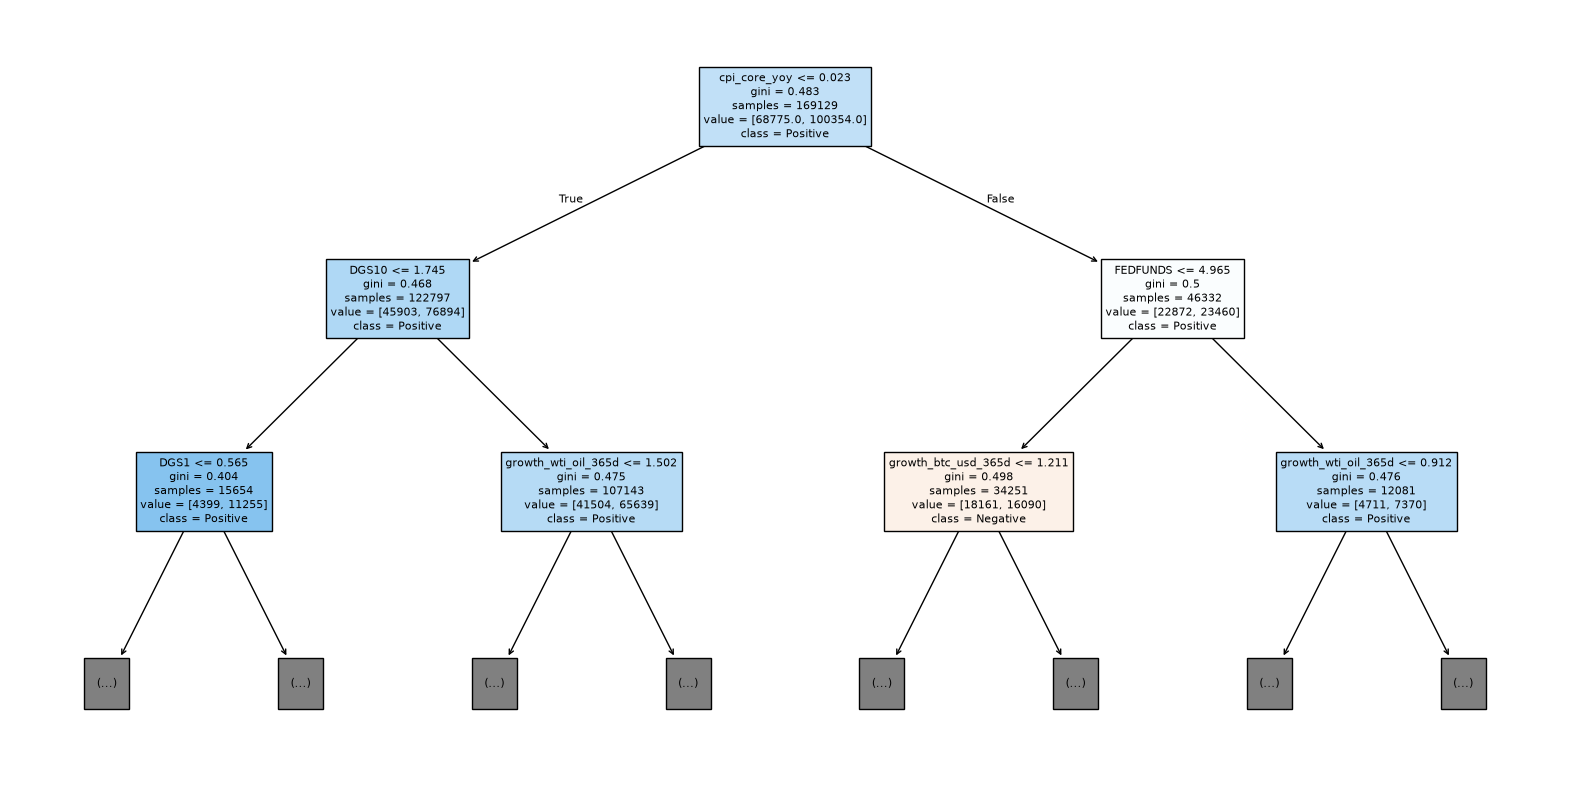

In [54]:
# visualisation: decision tree for a few levels (max_depth variable)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Assuming clf is your trained DecisionTreeClassifier
plt.figure(figsize=(20,10))  # Set the size of the figure
plot_tree(clf_10,
          filled=True,
          feature_names=train_columns,
          class_names=['Negative', 'Positive'],
          max_depth=2)
plt.show()


In [55]:
# Feautures importance function to predict future returns (based on the classifier)
# get feature importance from 'clf' (classifier) and 'train_columns' (column names)

def get_importances(clf, train_columns):
  # Assuming clf is your trained DecisionTreeClassifier
  feature_importance = clf.feature_importances_

  # Assuming X_train is your training features
  feature_names = train_columns

  # Create a DataFrame to store feature importance
  feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

  # Sort the DataFrame by importance in descending order
  feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

  # Print or display the feature importance DataFrame
  # print(feature_importance_df)
  return feature_importance_df

In [56]:
get_importances(clf_10, train_columns).head(10)

,Feature,Importance
178,cpi_core_yoy,0.064357
35,growth_gold_365d,0.051265
179,cpi_core_mom,0.047297
41,growth_wti_oil_365d,0.037639
93,ad,0.035552
180,FEDFUNDS,0.035215
95,obv,0.033785
53,growth_btc_usd_365d,0.031372
90,trix,0.030849
22,growth_dji_90d,0.030626


### Question 2: Define New "Hand" Rules on Macro and Technical Indicator Variables

In [57]:
# Define new prediction rules
new_df['pred3_manual_dgs10_5'] = ((new_df['DGS10'] <= 4.5) & (new_df['DGS5'] <= 4)).astype(int)
new_df['pred4_manual_dgs10_fedfunds'] = ((new_df['DGS10'] > 4) & (new_df['FEDFUNDS'] <= 4.795)).astype(int)

In [58]:
new_df[['pred4_manual_dgs10_fedfunds','pred3_manual_dgs10_5']].value_counts()

pred4_manual_dgs10_fedfunds  pred3_manual_dgs10_5
0                            1                       129190
                             0                        26570
1                            0                        23297
                             1                        23235
Name: count, dtype: int64

In [59]:
# Add to predictions list
PREDICTIONS += ['pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds']

In [60]:
# Generate is_correct columns
for pred in ['pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds']:
    part1 = pred.split('_')[0]
    new_df[f'is_correct_{part1}'] = (new_df[pred] == new_df['is_positive_growth_30d_future']).astype(int)
    IS_CORRECT.append(f'is_correct_{part1}')

In [61]:
# Evaluate precision for pred3 and pred4 on test split
for pred in ['pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds']:
    is_correct_col = f'is_correct_{pred.split("_")[0]}'

    # Filter: Only test split + rows where prediction is 1
    test_filter = (new_df['split'] == 'test') & (new_df[pred] == 1)
    num_preds = test_filter.sum()

    if num_preds > 0:
        # Precision = TP / (TP + FP)
        precision = new_df.loc[test_filter, is_correct_col].sum() / num_preds
        print(f"{pred} — Precision: {round(precision, 3)} — Positive Predictions: {num_preds}")
    else:
        print(f"{pred} — No positive predictions on test set.")

pred3_manual_dgs10_5 — Precision: 0.588 — Positive Predictions: 15910
pred4_manual_dgs10_fedfunds — Precision: 0.503 — Positive Predictions: 15921


In [62]:
# Look at macro value ranges in the test split
test_macro_stats = new_df[new_df['split'] == 'test'][['DGS10', 'DGS5', 'FEDFUNDS']].describe()
print(test_macro_stats)

              DGS10          DGS5      FEDFUNDS
count  33163.000000  33163.000000  33163.000000
mean       4.178523      4.041830      4.491248
std        0.344986      0.327864      0.695715
min        3.300000      3.290000      2.560000
25%        3.970000      3.770000      3.780000
50%        4.230000      4.030000      4.330000
75%        4.420000      4.290000      5.330000
max        5.010000      4.950000      5.330000


### Question 3: Unique Correct Predictions from a 10-Level Decision Tree Classifier (pred5_clf_10)

In [63]:
# Step 1: Build X_all / y_all for the entire dataset (TRAIN + VALIDATION + TEST)
# using the same cleaning steps as X_train / X_test
X_all = new_df[features_list + [to_predict]].copy()
X_all.replace([np.inf, -np.inf], np.nan, inplace=True)
X_all.fillna(0, inplace=True)

y_all = X_all[to_predict]
del X_all[to_predict]

print(f'length: X_all {X_all.shape}, y_all {y_all.shape}')

length: X_all (202292, 299), y_all (202292,)


In [64]:
# clf_10 was fitted above on TRAIN + VALIDATION with max_depth=10, random_state=42
# Predict on the entire dataset (same columns/order as used in training)
new_df['pred5_clf_10'] = clf_10.predict(X_all[train_columns])
new_df['pred5_clf_10'].value_counts()

pred5_clf_10
1    129811
0     72481
Name: count, dtype: int64

In [65]:
# Step 2: pred5 is correct, while all 'hand' rules (pred0..pred4) are incorrect
new_df['is_correct_pred5'] = (new_df['pred5_clf_10'] == new_df[to_predict]).astype(int)

hand_rules_is_correct = ['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2',
                         'is_correct_pred3', 'is_correct_pred4']

new_df['only_pred5_is_correct'] = (new_df['is_correct_pred5'] == 1) & (new_df[hand_rules_is_correct] == 0).all(axis=1)

In [66]:
# Step 3: Convert to int and count on the TEST set
new_df['only_pred5_is_correct'] = new_df['only_pred5_is_correct'].astype(int)

test_only_pred5 = new_df[new_df['split'] == 'test']
answer_q3 = (test_only_pred5['only_pred5_is_correct'] == 1).sum()
print(f'Records in TEST where only pred5_clf_10 is correct: {answer_q3}')

Records in TEST where only pred5_clf_10 is correct: 1229


#### Advanced (Optional): Generalised "uniquely correct" check for any prediction column

In [67]:
# All is_correct_ columns for pred0..pred5
IS_CORRECT_ALL = [f'is_correct_pred{i}' for i in range(6)]

def is_uniquely_correct(row, target_col, is_correct_cols):
    """
    Returns 1 if the prediction behind `target_col` is correct for this row
    while every other prediction in `is_correct_cols` is incorrect, else 0.
    """
    others = [c for c in is_correct_cols if c != target_col]
    return int(row[target_col] == 1 and all(row[c] == 0 for c in others))

In [68]:
# Apply row-wise for every prediction column -> only_predX_is_correct
for col in IS_CORRECT_ALL:
    pred = col.replace('is_correct_', '')  # e.g. 'pred3'
    new_df[f'only_{pred}_is_correct'] = new_df[IS_CORRECT_ALL].apply(
        is_uniquely_correct, axis=1, args=(col, IS_CORRECT_ALL))

ONLY_CORRECT = [f'only_pred{i}_is_correct' for i in range(6)]

In [69]:
# Count uniquely correct predictions per predictor on the TEST set
new_df[new_df['split'] == 'test'][ONLY_CORRECT].sum()

only_pred0_is_correct      99
only_pred1_is_correct     375
only_pred2_is_correct       1
only_pred3_is_correct    1021
only_pred4_is_correct    1622
only_pred5_is_correct    1229
dtype: int64

In [70]:
# Sanity check: the generalised function reproduces the Question 3 answer
assert new_df[new_df['split'] == 'test']['only_pred5_is_correct'].sum() == answer_q3
print(f'only_pred5_is_correct on TEST = {answer_q3} (matches Question 3)')

only_pred5_is_correct on TEST = 1229 (matches Question 3)


### Question 4: Hyperparameter tuning for a Decision Tree

In [71]:
from sklearn.tree import export_text

X_train_dt = X_train_imputed.drop(['Date', 'Ticker'], axis=1)
X_test_dt = X_test_imputed.drop(['Date', 'Ticker'], axis=1)

# VALIDATION rows are part of TRAIN+VALIDATION (index isn't unique across tickers -> use a positional mask)
is_val = (train_df['split'] == 'validation').values
X_val_dt, y_val = X_train_dt[is_val], y_train[is_val]
X_tr_dt, y_tr = X_train_dt[~is_val], y_train[~is_val]

In [72]:
# Iterate max_depth 1..20: fit on TRAIN+VALIDATION, track precision (and accuracy) on TRAIN, VALIDATION and TEST
precision_by_depth = []

for max_depth in range(1, 21):
    clf, _ = fit_decision_tree(X=X_train_dt, y=y_train, max_depth=max_depth)

    row = {'max_depth': max_depth}
    for name, X_, y_ in [('train', X_tr_dt, y_tr), ('validation', X_val_dt, y_val), ('test', X_test_dt, y_test)]:
        y_pred_ = clf.predict(X_)
        row[f'precision_{name}'] = precision_score(y_, y_pred_, zero_division=0)
        row[f'accuracy_{name}'] = accuracy_score(y_, y_pred_)
    precision_by_depth.append(row)

    # 'head' of the tree (top 2 levels) for a compact view of how it changes with depth
    print(f"===== max_depth={max_depth}: precision val={row['precision_validation']:.4f}, test={row['precision_test']:.4f}")
    print(export_text(clf, feature_names=list(X_train_dt), max_depth=2))

precision_by_depth_df = pd.DataFrame(precision_by_depth).set_index('max_depth')

===== max_depth=1: precision val=0.6014, test=0.5701
|--- cpi_core_yoy <= 0.02
|   |--- class: 1
|--- cpi_core_yoy >  0.02
|   |--- class: 1



===== max_depth=2: precision val=0.6647, test=0.6225
|--- cpi_core_yoy <= 0.02
|   |--- DGS10 <= 1.75
|   |   |--- class: 1
|   |--- DGS10 >  1.75
|   |   |--- class: 1
|--- cpi_core_yoy >  0.02
|   |--- FEDFUNDS <= 4.96
|   |   |--- class: 0
|   |--- FEDFUNDS >  4.96
|   |   |--- class: 1



===== max_depth=3: precision val=0.6422, test=0.5720
|--- cpi_core_yoy <= 0.02
|   |--- DGS10 <= 1.75
|   |   |--- DGS1 <= 0.56
|   |   |   |--- class: 1
|   |   |--- DGS1 >  0.56
|   |   |   |--- class: 0
|   |--- DGS10 >  1.75
|   |   |--- growth_wti_oil_365d <= 1.50
|   |   |   |--- class: 1
|   |   |--- growth_wti_oil_365d >  1.50
|   |   |   |--- class: 1
|--- cpi_core_yoy >  0.02
|   |--- FEDFUNDS <= 4.96
|   |   |--- growth_btc_usd_365d <= 1.21
|   |   |   |--- class: 0
|   |   |--- growth_btc_usd_365d >  1.21
|   |   |   |--- class: 1
|   |--- FEDFUNDS >  4.96
|   |   |--- growth_wti_oil_365d <= 0.91
|   |   |   |--- class: 0
|   |   |--- growth_wti_oil_365d >  0.91
|   |   |   |--- class: 1



===== max_depth=4: precision val=0.6532, test=0.6292
|--- cpi_core_yoy <= 0.02
|   |--- DGS10 <= 1.75
|   |   |--- DGS1 <= 0.56
|   |   |   |--- truncated branch of depth 2
|   |   |--- DGS1 >  0.56
|   |   |   |--- truncated branch of depth 2
|   |--- DGS10 >  1.75
|   |   |--- growth_wti_oil_365d <= 1.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- growth_wti_oil_365d >  1.50
|   |   |   |--- truncated branch of depth 2
|--- cpi_core_yoy >  0.02
|   |--- FEDFUNDS <= 4.96
|   |   |--- growth_btc_usd_365d <= 1.21
|   |   |   |--- truncated branch of depth 2
|   |   |--- growth_btc_usd_365d >  1.21
|   |   |   |--- truncated branch of depth 2
|   |--- FEDFUNDS >  4.96
|   |   |--- growth_wti_oil_365d <= 0.91
|   |   |   |--- truncated branch of depth 2
|   |   |--- growth_wti_oil_365d >  0.91
|   |   |   |--- truncated branch of depth 2



===== max_depth=5: precision val=0.6895, test=0.5991
|--- cpi_core_yoy <= 0.02
|   |--- DGS10 <= 1.75
|   |   |--- DGS1 <= 0.56
|   |   |   |--- truncated branch of depth 3
|   |   |--- DGS1 >  0.56
|   |   |   |--- truncated branch of depth 3
|   |--- DGS10 >  1.75
|   |   |--- growth_wti_oil_365d <= 1.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- growth_wti_oil_365d >  1.50
|   |   |   |--- truncated branch of depth 3
|--- cpi_core_yoy >  0.02
|   |--- FEDFUNDS <= 4.96
|   |   |--- growth_btc_usd_365d <= 1.21
|   |   |   |--- truncated branch of depth 3
|   |   |--- growth_btc_usd_365d >  1.21
|   |   |   |--- truncated branch of depth 3
|   |--- FEDFUNDS >  4.96
|   |   |--- growth_wti_oil_365d <= 0.91
|   |   |   |--- truncated branch of depth 3
|   |   |--- growth_wti_oil_365d >  0.91
|   |   |   |--- truncated branch of depth 3



...

===== max_depth=16: precision val=0.8908, test=0.5766
|--- cpi_core_yoy <= 0.02
|   |--- DGS10 <= 1.75
|   |   |--- DGS1 <= 0.56
|   |   |   |--- truncated branch of depth 14
|   |   |--- DGS1 >  0.56
|   |   |   |--- truncated branch of depth 14
|   |--- DGS10 >  1.75
|   |   |--- growth_wti_oil_365d <= 1.50
|   |   |   |--- truncated branch of depth 14
|   |   |--- growth_wti_oil_365d >  1.50
|   |   |   |--- truncated branch of depth 14
|--- cpi_core_yoy >  0.02
|   |--- FEDFUNDS <= 4.96
|   |   |--- growth_btc_usd_365d <= 1.21
|   |   |   |--- truncated branch of depth 14
|   |   |--- growth_btc_usd_365d >  1.21
|   |   |   |--- truncated branch of depth 14
|   |--- FEDFUNDS >  4.96
|   |   |--- growth_wti_oil_365d <= 0.91
|   |   |   |--- truncated branch of depth 14
|   |   |--- growth_wti_oil_365d >  0.91
|   |   |   |--- truncated branch of depth 14



===== max_depth=17: precision val=0.9055, test=0.5990
|--- cpi_core_yoy <= 0.02
|   |--- DGS10 <= 1.75
|   |   |--- DGS1 <= 0.56
|   |   |   |--- truncated branch of depth 15
|   |   |--- DGS1 >  0.56
|   |   |   |--- truncated branch of depth 15
|   |--- DGS10 >  1.75
|   |   |--- growth_wti_oil_365d <= 1.50
|   |   |   |--- truncated branch of depth 15
|   |   |--- growth_wti_oil_365d >  1.50
|   |   |   |--- truncated branch of depth 15
|--- cpi_core_yoy >  0.02
|   |--- FEDFUNDS <= 4.96
|   |   |--- growth_btc_usd_365d <= 1.21
|   |   |   |--- truncated branch of depth 15
|   |   |--- growth_btc_usd_365d >  1.21
|   |   |   |--- truncated branch of depth 15
|   |--- FEDFUNDS >  4.96
|   |   |--- growth_wti_oil_365d <= 0.91
|   |   |   |--- truncated branch of depth 15
|   |   |--- growth_wti_oil_365d >  0.91
|   |   |   |--- truncated branch of depth 15



===== max_depth=18: precision val=0.9255, test=0.5867
|--- cpi_core_yoy <= 0.02
|   |--- DGS10 <= 1.75
|   |   |--- DGS1 <= 0.56
|   |   |   |--- truncated branch of depth 16
|   |   |--- DGS1 >  0.56
|   |   |   |--- truncated branch of depth 16
|   |--- DGS10 >  1.75
|   |   |--- growth_wti_oil_365d <= 1.50
|   |   |   |--- truncated branch of depth 16
|   |   |--- growth_wti_oil_365d >  1.50
|   |   |   |--- truncated branch of depth 16
|--- cpi_core_yoy >  0.02
|   |--- FEDFUNDS <= 4.96
|   |   |--- growth_btc_usd_365d <= 1.21
|   |   |   |--- truncated branch of depth 16
|   |   |--- growth_btc_usd_365d >  1.21
|   |   |   |--- truncated branch of depth 16
|   |--- FEDFUNDS >  4.96
|   |   |--- growth_wti_oil_365d <= 0.91
|   |   |   |--- truncated branch of depth 16
|   |   |--- growth_wti_oil_365d >  0.91
|   |   |   |--- truncated branch of depth 16



===== max_depth=19: precision val=0.9308, test=0.5869
|--- cpi_core_yoy <= 0.02
|   |--- DGS10 <= 1.75
|   |   |--- DGS1 <= 0.56
|   |   |   |--- truncated branch of depth 17
|   |   |--- DGS1 >  0.56
|   |   |   |--- truncated branch of depth 17
|   |--- DGS10 >  1.75
|   |   |--- growth_wti_oil_365d <= 1.50
|   |   |   |--- truncated branch of depth 17
|   |   |--- growth_wti_oil_365d >  1.50
|   |   |   |--- truncated branch of depth 17
|--- cpi_core_yoy >  0.02
|   |--- FEDFUNDS <= 4.96
|   |   |--- growth_btc_usd_365d <= 1.21
|   |   |   |--- truncated branch of depth 17
|   |   |--- growth_btc_usd_365d >  1.21
|   |   |   |--- truncated branch of depth 17
|   |--- FEDFUNDS >  4.96
|   |   |--- growth_wti_oil_365d <= 0.91
|   |   |   |--- truncated branch of depth 17
|   |   |--- growth_wti_oil_365d >  0.91
|   |   |   |--- truncated branch of depth 17



===== max_depth=20: precision val=0.9464, test=0.5924
|--- cpi_core_yoy <= 0.02
|   |--- DGS10 <= 1.75
|   |   |--- DGS1 <= 0.56
|   |   |   |--- truncated branch of depth 18
|   |   |--- DGS1 >  0.56
|   |   |   |--- truncated branch of depth 18
|   |--- DGS10 >  1.75
|   |   |--- growth_wti_oil_365d <= 1.50
|   |   |   |--- truncated branch of depth 18
|   |   |--- growth_wti_oil_365d >  1.50
|   |   |   |--- truncated branch of depth 18
|--- cpi_core_yoy >  0.02
|   |--- FEDFUNDS <= 4.96
|   |   |--- growth_btc_usd_365d <= 1.21
|   |   |   |--- truncated branch of depth 18
|   |   |--- growth_btc_usd_365d >  1.21
|   |   |   |--- truncated branch of depth 18
|   |--- FEDFUNDS >  4.96
|   |   |--- growth_wti_oil_365d <= 0.91
|   |   |   |--- truncated branch of depth 18
|   |   |--- growth_wti_oil_365d >  0.91
|   |   |   |--- truncated branch of depth 18



In [73]:
precision_by_depth_df

,precision_train,accuracy_train,precision_validation,accuracy_validation,precision_test,accuracy_test
max_depth,,,,,,
1,0.591449,0.591449,0.601449,0.601449,0.570093,0.570093
2,0.619459,0.616514,0.664658,0.559358,0.622534,0.516811
3,0.628261,0.618502,0.642214,0.632236,0.571969,0.491813
4,0.630278,0.625093,0.653223,0.666119,0.629175,0.481923
5,0.638193,0.640432,0.689521,0.685694,0.599081,0.474143
6,0.644452,0.648997,0.710403,0.697339,0.596578,0.472123
7,0.660912,0.665329,0.705778,0.713817,0.622891,0.478666
8,0.668151,0.677409,0.737082,0.730232,0.619370,0.497995
9,0.700146,0.698981,0.753708,0.749249,0.595607,0.484244


In [74]:
best_max_depth = precision_by_depth_df['precision_test'].idxmax()
print(f'best_max_depth = {best_max_depth}, TEST precision = {precision_by_depth_df.loc[best_max_depth, "precision_test"]:.4f}')

best_max_depth = 4, TEST precision = 0.6292


In [75]:
# Retrain with best_max_depth on TRAIN+VALIDATION and predict on the entire dataset
clf_best, _ = fit_decision_tree(X=X_train_dt, y=y_train, max_depth=best_max_depth)

new_df['pred6_clf_best'] = clf_best.predict(X_all[train_columns])
new_df['is_correct_pred6'] = (new_df['pred6_clf_best'] == new_df[to_predict]).astype(int)

In [76]:
# Compare TEST precision of all predictions pred0..pred6
test_df_all = new_df[new_df['split'] == 'test']
ALL_PREDICTIONS = PREDICTIONS + ['pred5_clf_10', 'pred6_clf_best']

precision_comparison = pd.DataFrame({
    'precision_test': [precision_score(test_df_all[to_predict], test_df_all[p], zero_division=0) for p in ALL_PREDICTIONS],
    'positive_predictions': [test_df_all[p].sum() for p in ALL_PREDICTIONS],
}, index=ALL_PREDICTIONS)
precision_comparison.sort_values('precision_test', ascending=False)

,precision_test,positive_predictions
pred6_clf_best,0.629175,6677
pred5_clf_10,0.599343,8219
pred3_manual_dgs10_5,0.587744,15910
pred1_manual_prev_g1,0.578662,19158
pred2_manual_prev_g1_and_snp,0.572553,15244
pred0_manual_cci,0.564604,921
pred4_manual_dgs10_fedfunds,0.502544,15921


#### Advanced (Optional): Precision / accuracy vs max_depth — complexity vs generalization

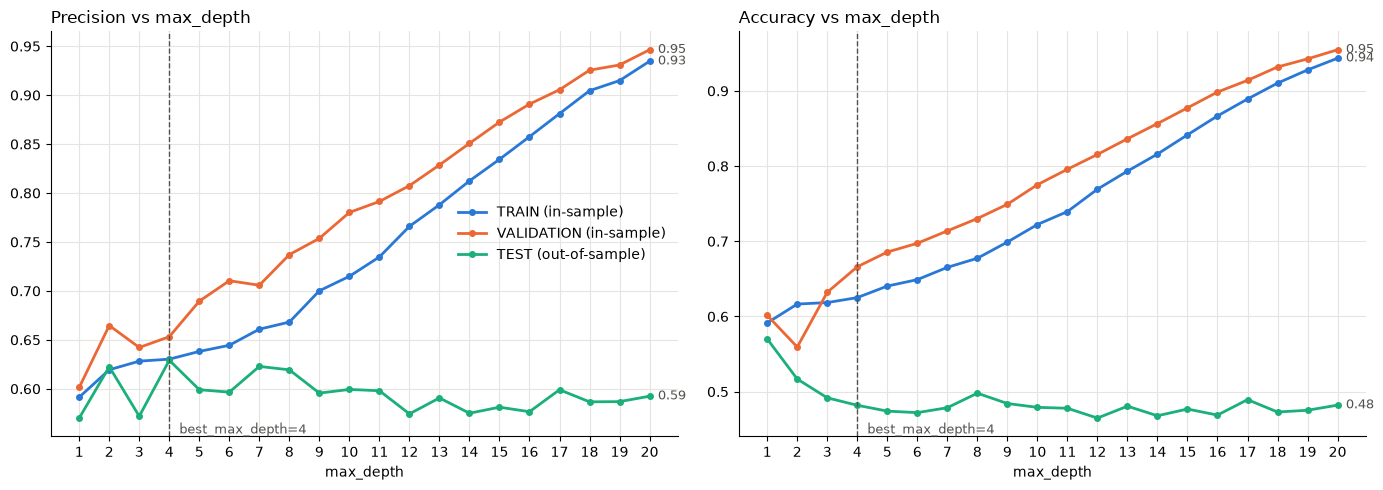

In [77]:
# TRAIN and VALIDATION are in-sample (the trees are fitted on TRAIN+VALIDATION); TEST is out-of-sample
SERIES = [('train', 'TRAIN (in-sample)', '#2a78d6'),
          ('validation', 'VALIDATION (in-sample)', '#eb6834'),
          ('test', 'TEST (out-of-sample)', '#1baf7a')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, metric in zip(axes, ['precision', 'accuracy']):
    for split_name, label, color in SERIES:
        s = precision_by_depth_df[f'{metric}_{split_name}']
        ax.plot(s.index, s.values, color=color, linewidth=2, marker='o', markersize=4, label=label)
        ax.annotate(f'{s.iloc[-1]:.2f}', (s.index[-1], s.iloc[-1]), xytext=(6, 0),
                    textcoords='offset points', va='center', fontsize=9, color='#52514e')
    ax.axvline(best_max_depth, color='#52514e', linestyle='--', linewidth=1)
    ax.text(best_max_depth + 0.2, ax.get_ylim()[0], f' best_max_depth={best_max_depth}',
            va='bottom', fontsize=9, color='#52514e')
    ax.set_title(f'{metric.capitalize()} vs max_depth', loc='left')
    ax.set_xlabel('max_depth')
    ax.set_xticks(range(1, 21))
    ax.grid(True, color='#e5e4e0', linewidth=0.8)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

In [78]:
# Generalization gap: in-sample (TRAIN+VALIDATION rows) vs out-of-sample (TEST)
gap_df = pd.DataFrame({
    'precision_gap_val_minus_test': precision_by_depth_df['precision_validation'] - precision_by_depth_df['precision_test'],
    'accuracy_gap_train_minus_test': precision_by_depth_df['accuracy_train'] - precision_by_depth_df['accuracy_test'],
})
pd.concat([precision_by_depth_df, gap_df], axis=1).round(3)

,precision_train,accuracy_train,precision_validation,accuracy_validation,precision_test,accuracy_test,precision_gap_val_minus_test,accuracy_gap_train_minus_test
max_depth,,,,,,,,
1,0.591,0.591,0.601,0.601,0.570,0.570,0.031,0.021
2,0.619,0.617,0.665,0.559,0.623,0.517,0.042,0.100
3,0.628,0.619,0.642,0.632,0.572,0.492,0.070,0.127
4,0.630,0.625,0.653,0.666,0.629,0.482,0.024,0.143
5,0.638,0.640,0.690,0.686,0.599,0.474,0.090,0.166
6,0.644,0.649,0.710,0.697,0.597,0.472,0.114,0.177
7,0.661,0.665,0.706,0.714,0.623,0.479,0.083,0.187
8,0.668,0.677,0.737,0.730,0.619,0.498,0.118,0.179
9,0.700,0.699,0.754,0.749,0.596,0.484,0.158,0.215


**Observations (complexity vs. generalization):**
- **Overfitting:** TRAIN/VALIDATION precision and accuracy rise almost linearly with depth (≈0.60 → 0.95), while TEST precision stays flat at ~0.57–0.63. The in-sample vs. TEST gap grows from ~0.02–0.03 at depth 1 to ~0.35 (precision) / ~0.46 (accuracy) at depth 20.
- **Saturation:** TEST precision peaks early (depth 4 ≈ 0.629, with depths 2, 7 and 8 close behind) and never improves after that; the extra depth only memorises the training period.
- **Accuracy vs. precision:** TEST accuracy drops below 0.5 after depth 2 even though precision stays ~0.6, because the trees predict "positive" rarely (e.g. 6,677 of 33,163 TEST rows at depth 4) and miss many actual positives. They are only useful for the "when to buy" (precision) use case.
- **Trade-off:** a shallow tree (depth ~4) gives the best out-of-sample precision with a small generalization gap and is easy to interpret.

### [EXPLORATORY] Question 5: What data is missing?

The most influential features (`cpi_core_yoy`, `cpi_core_mom`, `FEDFUNDS`, `DGS10`, `growth_gold_365d`, `growth_wti_oil_365d`) are macro series that are identical for every stock on a given date. The best tree (depth 4) splits *only* on them, so the model mostly learns *which market regime a date falls in*, not *which stock to pick*. New indicators I would add:

1. **Stock-specific fundamentals & events** – earnings surprise (EPS actual vs. estimate), days to next earnings, P/E, EV/EBITDA, revenue/margin growth, analyst revisions, short interest.
   *Why:* on any given date, only company-level data can tell the 33 stocks apart.

2. **Risk & sentiment** – VIX and its term structure (VIX vs. VIX3M), credit spreads (high-yield OAS, BAA–10Y), put/call ratio, dollar index (DXY).
   *Why:* rates and inflation describe the policy regime, but risk appetite, which often drives 30-day returns, is missing entirely.

3. **Regime-robust rate & inflation features** – yield-curve slopes (10Y–2Y, 10Y–3M), real yields (TIPS), breakeven inflation, and *changes* in rates (e.g. 3-month ΔDGS10) instead of levels.
   *Why:* splits like `DGS10 <= 1.75` or `FEDFUNDS <= 4.96` only fit one historical period (e.g. `pred4` (`DGS10 > 4 & FEDFUNDS <= 4.795`) drops to ~0.50 precision on TEST, a coin flip); slopes and changes carry over across periods.
